In [16]:
import pandas as pd

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

In [18]:
df = pd.read_csv('exchange_rates.csv')
df

,Series Description,SPOT EXCHANGE RATE - EURO AREA,"UNITED KINGDOM -- SPOT EXCHANGE RATE, US$/POUND (1/RXI_N.B.UK)",SPOT EXCHANGE RATE - BRAZIL,"CHINA -- SPOT EXCHANGE RATE, YUAN/US$ P.R.","DENMARK -- SPOT EXCHANGE RATE, KRONER/US$","INDIA -- SPOT EXCHANGE RATE, RUPEES/US$","JAPAN -- SPOT EXCHANGE RATE, YEN/US$","KOREA -- SPOT EXCHANGE RATE, WON/US$","MALAYSIA -- SPOT EXCHANGE RATE, RINGGIT/US$",...,"THAILAND -- SPOT EXCHANGE RATE, BAHT/US$",SPOT EXCHANGE RATE - VENEZUELA,Nominal Broad Dollar Index,Nominal Major Currencies Dollar Index,Nominal Other Important Trading Partners Dollar Index,AUSTRALIA -- SPOT EXCHANGE RATE US$/AU$ (RECIPROCAL OF RXI_N.B.AL),"NEW ZEALAND -- SPOT EXCHANGE RATE, US$/NZ$ RECIPROCAL OF RXI_N.B.NZ","CANADA -- SPOT EXCHANGE RATE, CANADIAN $/US$","HONG KONG -- SPOT EXCHANGE RATE, HK$/US$","SRI LANKA -- SPOT EXCHANGE RATE, RUPEES/US$"
0,Unit:,Currency:_Per_EUR,Currency:_Per_GBP,Currency:_Per_USD,Currency:_Per_USD,Currency:_Per_USD,Currency:_Per_USD,Currency:_Per_USD,Currency:_Per_USD,Currency:_Per_USD,...,Currency:_Per_USD,Currency:_Per_USD,Index:_1973_Mar_100,Index:_1973_Mar_100,Index:_1997_Jan_100,Currency:_Per_AUD,Currency:_Per_NZD,Currency:_Per_USD,Currency:_Per_USD,Currency:_Per_USD
1,Multiplier:,1,0.00999999978,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
2,Currency:,USD,USD,BRL,CNY,DKK,INR,JPY,KRW,MYR,...,THB,VEB,NaN,NaN,NaN,USD,USD,CAD,HKD,LKR
3,Unique Identifier:,H10/H10/RXI$US_N.B.EU,H10/H10/RXI$US_N.B.UK,H10/H10/RXI_N.B.BZ,H10/H10/RXI_N.B.CH,H10/H10/RXI_N.B.DN,H10/H10/RXI_N.B.IN,H10/H10/RXI_N.B.JA,H10/H10/RXI_N.B.KO,H10/H10/RXI_N.B.MA,...,H10/H10/RXI_N.B.TH,H10/H10/RXI_N.B.VE,H10/H10/JRXWTFB_N.B,H10/H10/JRXWTFN_N.B,H10/H10/JRXWTFO_N.B,H10/H10/RXI$US_N.B.AL,H10/H10/RXI$US_N.B.NZ,H10/H10/RXI_N.B.CA,H10/H10/RXI_N.B.HK,H10/H10/RXI_N.B.SL
4,Time Period,RXI$US_N.B.EU,RXI$US_N.B.UK,RXI_N.B.BZ,RXI_N.B.CH,RXI_N.B.DN,RXI_N.B.IN,RXI_N.B.JA,RXI_N.B.KO,RXI_N.B.MA,...,RXI_N.B.TH,RXI_N.B.VE,JRXWTFB_N.B,JRXWTFN_N.B,JRXWTFO_N.B,RXI$US_N.B.AL,RXI$US_N.B.NZ,RXI_N.B.CA,RXI_N.B.HK,RXI_N.B.SL
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12170,2017-08-21,1.1814,1.2903,3.1436,6.6630,6.2959,64.1000,108.8900,1137.1400,4.2855,...,33.2400,9.9750,119.1024,88.0441,152.4720,0.7936,0.7326,1.2587,7.8252,153.1000
12171,2017-08-22,1.1762,1.2834,3.1505,6.6600,6.3233,64.0700,109.4000,1131.7900,4.2790,...,33.2400,9.9750,119.1862,88.2744,152.3615,0.7913,0.7292,1.2559,7.8263,152.9000
12172,2017-08-23,1.1802,1.2787,3.1521,6.6569,6.3019,64.0400,109.1400,1128.5900,4.2780,...,33.3400,9.9750,119.1464,88.1510,152.4319,0.7893,0.7208,1.2558,7.8259,152.9000
12173,2017-08-24,1.1801,1.2802,3.1428,6.6600,6.3018,64.0400,109.3400,1127.8000,4.2780,...,33.3400,9.9750,119.0992,88.0944,152.3997,0.7905,0.7215,1.2528,7.8239,152.9000


In [19]:
df_australia = df[['Series Description','AUSTRALIA -- SPOT EXCHANGE RATE US$/AU$ (RECIPROCAL OF RXI_N.B.AL)']]
df_australia.describe()

,Series Description,AUSTRALIA -- SPOT EXCHANGE RATE US$/AU$ (RECIPROCAL OF RXI_N.B.AL)
count,12175,12175
unique,12175,4702
top,Unit:,ND
freq,1,468


In [20]:
# Se renombro la columna a "Exchange Rate" para facilitar su uso
df_australia = df_australia.rename(columns={'AUSTRALIA -- SPOT EXCHANGE RATE US$/AU$ (RECIPROCAL OF RXI_N.B.AL)': 'Exchange Rate'})

# Se cargó todo el `csv` brindando por el docente, por facilidad se modificó y se creó un nuevo df solo con los datos de `Australia` y las `fechas`. Se renombró la columna de Australia para facilitar su uso en todo el análisis.

In [21]:
df_australia.value_counts('Exchange Rate')

Exchange Rate
ND        468
1.1910    220
1.4850    106
1.4825     77
1.4150     75
         ... 
0.7811      1
0.7926      1
0.7949      1
0.7924      1
0.7929      1
Name: count, Length: 4702, dtype: int64

# Después de analizar las diferentes columnas se usarán los datos de Australia ya que cuenta con 4702 valores distintos y no tiene ningun valor null, pero si cuenta con 468 datos marcados como "ND", creemos que hace referencia a "No Data", se tomará la desición de imputar los datos para no afectar el módelo, ya que si se elimina sería casí un 10%, y en series de tiempo no es lo ideal.

### 1. Limpieza de Datos
Identificaremos los valores "ND" en la columna `Exchange Rate` y los reemplazaremos por una interpolación temporal para no perder la continuidad de la serie.

Total de valores nulos después de la imputación: 0


C:\Users\jsanc\AppData\Local\Temp\ipykernel_15268\2317947065.py:6: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_australia['Date'] = pd.to_datetime(df_australia['Date'], errors='coerce')


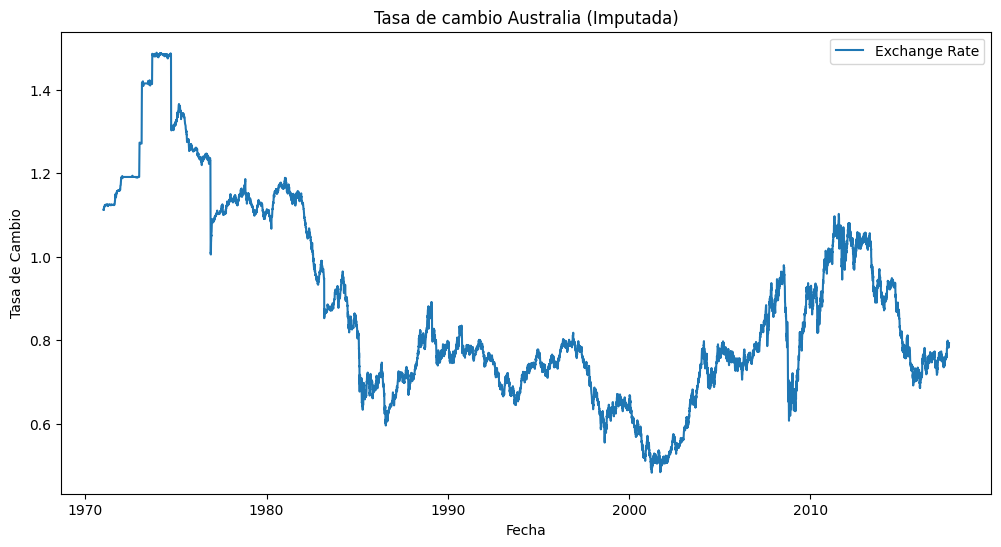

In [22]:
# Renombramos "Series Description" a "Date" para mayor claridad y limpiamos filas basura
if 'Series Description' in df_australia.columns:
    df_australia = df_australia.rename(columns={'Series Description': 'Date'})

# Intentamos convertir la columna Date a datetime. Las primeras filas que no son fechas quedarán como NaT y las eliminamos
df_australia['Date'] = pd.to_datetime(df_australia['Date'], errors='coerce')
df_australia = df_australia.dropna(subset=['Date'])
df_australia = df_australia.sort_values('Date').reset_index(drop=True)

# Reemplazar "ND" por NaN
df_australia['Exchange Rate'] = df_australia['Exchange Rate'].replace('ND', np.nan)
df_australia['Exchange Rate'] = pd.to_numeric(df_australia['Exchange Rate'], errors='coerce')

# Aplicar interpolación lineal para rellenar los datos faltantes
# Se usa interpolación lineal sobre ffill porque en las finanzas captura mejor las tendencias suaves entre dos puntos válidos
df_australia['Exchange Rate'] = df_australia['Exchange Rate'].interpolate(method='linear')

print(f"Total de valores nulos después de la imputación: {df_australia['Exchange Rate'].isnull().sum()}")
plt.figure(figsize=(12, 6))
plt.plot(df_australia['Date'], df_australia['Exchange Rate'], label='Exchange Rate')
plt.title('Tasa de cambio Australia (Imputada)')
plt.xlabel('Fecha')
plt.ylabel('Tasa de Cambio')
plt.legend()
plt.show()

### 2 y 3. Ventanas Temporales y Preparación de Datos para el Modelo
Se usa la regla de datos pasados ("lookback") para predecir un valor futuro ("horizonte"). Escalaremos los datos para facilitar el entrenamiento de la red profunda.

In [23]:

from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Configuración de Ventanas
WINDOW_SIZE = 30 # Datos pasados
HORIZON = 1      # Horizonte de predicción

# Extraer solo la serie temporal
series_data = df_australia[['Exchange Rate']].values

# Escalar los datos (las redes neuronales prefieren datos entre 0 y 1 o -1 y 1)
scaler = MinMaxScaler(feature_range=(0, 1))
series_scaled = scaler.fit_transform(series_data)

X, y = [], []
for i in range(len(series_scaled) - WINDOW_SIZE - HORIZON + 1):
    X.append(series_scaled[i : i + WINDOW_SIZE, 0])
    # Predecir el siguiente valor después de la ventana
    y.append(series_scaled[i + WINDOW_SIZE + HORIZON - 1, 0])

X = np.array(X)
y = np.array(y)

# Dividir en Train y Test (80% / 20%) respetando el orden temporal
split_idx = int(len(X) * 0.8)
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

print(f"Forma de X_train: {X_train.shape}")
print(f"Forma de y_train: {y_train.shape}")

Forma de X_train: (9712, 30)
Forma de y_train: (9712,)


### Arquitectura de Red Neuronal (Deep Learning)
Se usa un Multi Layer Perceptron (MLP) utilizando la API Sequential.

c:\Users\jsanc\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 64)             │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,097 (16.00 KB)

 Trainable params: 4,097 (16.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
304/304 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0107 - val_loss: 0.0016
Epoch 2/50
304/304 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0049 - val_loss: 9.6243e-04
Epoch 3/50
304/304 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0035 - val_loss: 0.0016
Epoch 4/50
304/304 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0031 - val_loss: 0.0026
Epoch 5/50
304/304 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0028 - val_loss: 9.5519e-04
Epoch 6/50
304/304 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0025 - val_loss: 0.0016
Epoch 7/50
304/304 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0024 - val_loss: 0.0021
Epoch 8/50
304/304 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0023 - val_loss: 0.0014
Epoch 9/50
304/304 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0022 - val_loss: 0.0010
Epoch 10/50
304/304 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0021 - val_loss: 0.0011
Epoch 11/50
304/304 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0020 - val_loss: 0.0014
Epoch 12/50
304/304 ━━━━━━━━━━━━━━━━━━━━ 1s 

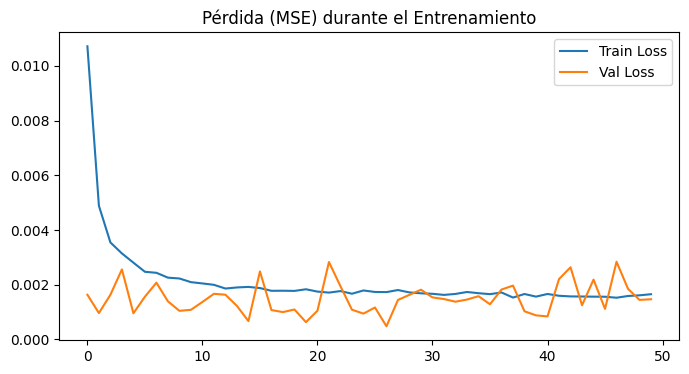

In [24]:
# 2. Arquitectura
from tensorflow.keras.layers import Dropout

model = Sequential([
    # Capa de entrada y primera capa oculta (relu nos ayuda a modelos no lineales sin saturación)
    Dense(64, activation='relu', input_shape=(WINDOW_SIZE,)),
    Dropout(0.2), # Añadimos Dropout para reducir el sobreajuste
    # Segunda capa oculta
    Dense(32, activation='relu'),
    Dropout(0.2), # Otro Dropout
    # Capa de salida continua
    Dense(1, activation='linear')
])

model.compile(optimizer='adam', loss='mse')
model.summary()

# Entrenar el modelo
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=1
)

# Evaluar el modelo visualmente en Loss
plt.figure(figsize=(8, 4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Pérdida (MSE) durante el Entrenamiento')
plt.legend()
plt.show()

In [25]:
# Predicciones
train_predictions = model.predict(X_train)
test_predictions = model.predict(X_test)

# Invertir el escalado
train_predictions = scaler.inverse_transform(train_predictions)
test_predictions = scaler.inverse_transform(test_predictions)
y_train_inv = scaler.inverse_transform(y_train.reshape(-1, 1))
y_test_inv = scaler.inverse_transform(y_test.reshape(-1, 1))

# Calcular RMSE
train_rmse = np.sqrt(mean_squared_error(y_train_inv, train_predictions))
test_rmse = np.sqrt(mean_squared_error(y_test_inv, test_predictions))
print(f"Train RMSE: {train_rmse:.4f}")
print(f"Test RMSE: {test_rmse:.4f}")

304/304 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Train RMSE: 0.0582
Test RMSE: 0.0385


### 4. Interactividad
El usuario puede ingresar un rango de fechas para visualizar los datos históricos y la predicción generada que cae dentro de ese rango de fechas.

In [26]:
import ipywidgets as widgets
from IPython.display import display

# Preparar un dataframe con todas las predicciones para facilitar el filtrado por fechas
all_dates = df_australia['Date'].values[WINDOW_SIZE + HORIZON - 1:]
all_real = np.concatenate([y_train_inv, y_test_inv]).flatten()
all_preds = np.concatenate([train_predictions, test_predictions]).flatten()

df_results = pd.DataFrame({
    'Date': all_dates,
    'Real Exchange Rate': all_real,
    'Predicción NN': all_preds
})
df_results['Date'] = pd.to_datetime(df_results['Date'])

def plot_interactive_range(start_date, end_date):
    start_date = pd.to_datetime(start_date)
    end_date = pd.to_datetime(end_date)

    mask = (df_results['Date'] >= start_date) & (df_results['Date'] <= end_date)
    df_filtered = df_results.loc[mask]

    if df_filtered.empty:
        print("No hay datos en este rango de fechas. Intente con un rango diferente (Ej. entre 1971 y 2011).")
        return

    plt.figure(figsize=(12, 6))
    plt.plot(df_filtered['Date'], df_filtered['Real Exchange Rate'], label='Real', marker='o', markersize=2)
    plt.plot(df_filtered['Date'], df_filtered['Predicción NN'], label='Predicción', alpha=0.8)

    plt.title(f'Tasa de Cambio Real vs Predicha ({start_date.date()} a {end_date.date()})')
    plt.xlabel('Fecha')
    plt.ylabel('Tasa de Cambio')
    plt.legend()
    plt.grid(True)
    plt.show()

# Widgets para seleccionar fechas
start_date_picker = widgets.DatePicker(
    description='Fecha Inicio',
    disabled=False,
    value=pd.to_datetime('2000-01-01').date()
)

end_date_picker = widgets.DatePicker(
    description='Fecha Fin',
    disabled=False,
    value=pd.to_datetime('2000-12-31').date()
)

interact_box = widgets.interactive(plot_interactive_range, start_date=start_date_picker, end_date=end_date_picker)
display(interact_box)

interactive(children=(DatePicker(value=datetime.date(2000, 1, 1), description='Fecha Inicio', step=1), DatePic…

In [27]:
from IPython.display import display
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Tomar los últimos datos escalados (del final de nuestro dataset) como base de partida
last_known_window = series_scaled[-WINDOW_SIZE:]
last_date = df_australia['Date'].iloc[-1]

def plot_future_forecast(meses_a_predecir):
    if meses_a_predecir <= 0:
        print("Mínimo 1 mes de predicción.")
        return

    # Asumimos que 1 mes ~ 22 días laborables/hábiles en Forex approx (o 30 calendario, usaremos 30 general)
    dias_a_predecir = meses_a_predecir * 30

    # Predecir iterativamente alimentando los inputs nuevos
    future_preds = []
    current_window = last_known_window.copy()

    for _ in range(dias_a_predecir):
        # La red espera un tensor con la forma (1, WINDOW_SIZE)
        pred = model.predict(current_window.reshape(1, WINDOW_SIZE), verbose=0)[0, 0]
        future_preds.append(pred)
        # Desplazamos la ventana: quitamos el más antiguo y añadimos la nueva predicción al final
        current_window = np.append(current_window[1:], [[pred]], axis=0)

    # Invertir el escalado de las predicciones a la magnitud real del Exchange Rate
    future_preds = scaler.inverse_transform(np.array(future_preds).reshape(-1, 1)).flatten()

    # Generar rango de fechas futuras excluyendo fines de semana (comportamiento de bolsa local)
    future_dates = pd.bdate_range(start=last_date + pd.Timedelta(days=1), periods=dias_a_predecir)

    # Contexto visual de los últimos 365 días reales
    context_days = 365
    hist_dates = df_australia['Date'].iloc[-context_days:]
    hist_values = df_australia['Exchange Rate'].iloc[-context_days:]

    plt.figure(figsize=(14, 6))
    plt.plot(hist_dates, hist_values, label='Datos Históricos (último año)', color='blue')
    plt.plot(future_dates, future_preds, label='Predicciones Futuras', color='crimson', linestyle='--')

    # Marcar evento de quiebre entre pasado y futuro predictivo
    plt.axvline(x=last_date, color='grey', linestyle=':', label='Fin datos reales')

    plt.title(f'Proyección de Tasa de Cambio (Forecasting iterativo {meses_a_predecir} meses)')
    plt.xlabel('Fecha')
    plt.ylabel('Tasa de Cambio')
    plt.legend()
    plt.grid(True)
    plt.show()

    # Mostrar los valores numéricos de las predicciones
    df_forecast = pd.DataFrame({
        'Fecha': future_dates,
        'Predicción Tasa de Cambio': future_preds
    })
    print("\nValores numéricos de las predicciones futuras (primeras 10 filas):")
    display(df_forecast.head(10))
    if len(df_forecast) > 10:
        print(f"... y {len(df_forecast) - 10} filas más. Para ver todas, ajuste el slider o imprima `df_forecast`.")

# Widget deslizante interactivo
slider_meses = widgets.IntSlider(
    value=4,     # 4 meses permite visualizar el resto del año 2017
    min=1,
    max=60,      # Posibilidad de visualizar hasta 5 años en adelante
    step=1,
    description='Meses Futuros (n):',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='60%')
)

interact_forecast = widgets.interactive(plot_future_forecast, meses_a_predecir=slider_meses)
display(interact_forecast)

interactive(children=(IntSlider(value=4, description='Meses Futuros (n):', layout=Layout(width='60%'), max=60,…

### Implementación de Red Neuronal LSTM (Long Short-Term Memory)
Para capturar mejor las dependencias secuenciales a largo plazo, configuraremos y entrenaremos un modelo LSTM. Adaptaremos nuestros datos de entrada porque las capas LSTM esperan un formato tridimensional: `(muestras, pasos_de_tiempo, características)`.

Forma original de X_train: (9712, 30)
Nueva forma de X_train_lstm: (9712, 30, 1)


c:\Users\jsanc\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 30, 100)        │        40,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 30, 100)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 50)             │        30,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 25)             │         1,275 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 72,301 (282.43 KB)

 Trainable params: 72,301 (282.43 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
304/304 ━━━━━━━━━━━━━━━━━━━━ 12s 28ms/step - loss: 0.0062 - val_loss: 0.0016
Epoch 2/50
304/304 ━━━━━━━━━━━━━━━━━━━━ 8s 26ms/step - loss: 0.0014 - val_loss: 3.7212e-04
Epoch 3/50
304/304 ━━━━━━━━━━━━━━━━━━━━ 8s 26ms/step - loss: 8.4303e-04 - val_loss: 0.0014
Epoch 4/50
304/304 ━━━━━━━━━━━━━━━━━━━━ 8s 27ms/step - loss: 6.5758e-04 - val_loss: 0.0020
Epoch 5/50
304/304 ━━━━━━━━━━━━━━━━━━━━ 8s 26ms/step - loss: 5.8170e-04 - val_loss: 0.0017
Epoch 6/50
304/304 ━━━━━━━━━━━━━━━━━━━━ 8s 26ms/step - loss: 4.7164e-04 - val_loss: 0.0011
Epoch 7/50
304/304 ━━━━━━━━━━━━━━━━━━━━ 8s 26ms/step - loss: 4.3950e-04 - val_loss: 0.0015
Epoch 8/50
304/304 ━━━━━━━━━━━━━━━━━━━━ 8s 27ms/step - loss: 3.9105e-04 - val_loss: 0.0014
Epoch 9/50
304/304 ━━━━━━━━━━━━━━━━━━━━ 8s 26ms/step - loss: 4.0428e-04 - val_loss: 0.0011
Epoch 10/50
304/304 ━━━━━━━━━━━━━━━━━━━━ 8s 27ms/step - loss: 3.4641e-04 - val_loss: 0.0012
Epoch 11/50
304/304 ━━━━━━━━━━━━━━━━━━━━ 8s 26ms/step - loss: 3.5579e-04 - val_loss: 8.5378e

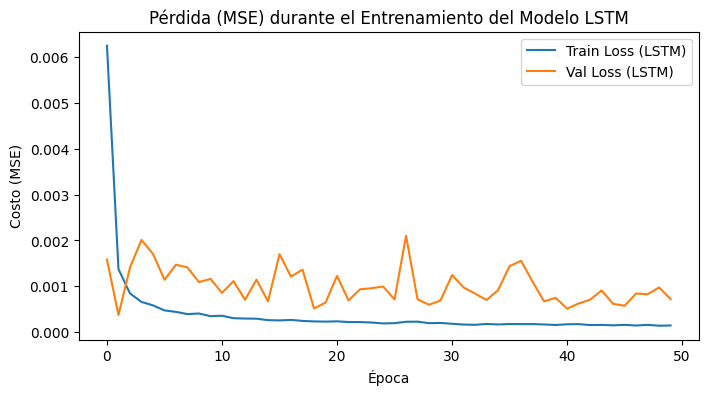

In [28]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# Redimensionar los datos de [muestras, ventana] a [muestras, pasos de tiempo (ventana), características]
# La cantidad de características es 1 (la tasa de cambio)
X_train_lstm = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test_lstm = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

print(f"Forma original de X_train: {X_train.shape}")
print(f"Nueva forma de X_train_lstm: {X_train_lstm.shape}")

# Definir la arquitectura LSTM mejorada
lstm_model = Sequential([
    LSTM(100, activation='relu', input_shape=(WINDOW_SIZE, 1), return_sequences=True), # Primera capa LSTM, ahora retorna secuencias
    Dropout(0.2), # Dropout para reducir el sobreajuste
    LSTM(50, activation='relu', return_sequences=False), # Segunda capa LSTM
    Dropout(0.2), # Otro Dropout
    Dense(25, activation='relu'),
    Dense(1, activation='linear')
])

lstm_model.compile(optimizer='adam', loss='mse')
lstm_model.summary()

# Entrenar modelo
history_lstm = lstm_model.fit(
    X_train_lstm, y_train,
    epochs=50, # Aumentamos las épocas para permitir más entrenamiento con la nueva arquitectura
    batch_size=32,
    validation_data=(X_test_lstm, y_test),
    verbose=1
)

# Evaluar visualmente el historial de pérdida
plt.figure(figsize=(8, 4))
plt.plot(history_lstm.history['loss'], label='Train Loss (LSTM)')
plt.plot(history_lstm.history['val_loss'], label='Val Loss (LSTM)')
plt.title('Pérdida (MSE) durante el Entrenamiento del Modelo LSTM')
plt.xlabel('Época')
plt.ylabel('Costo (MSE)')
plt.legend()
plt.show()

In [29]:
# Predicciones y cálculo del error con el modelo LSTM
train_predictions_lstm = lstm_model.predict(X_train_lstm)
test_predictions_lstm = lstm_model.predict(X_test_lstm)

# Invertir el escalado de nuevo a los valores reales
train_predictions_lstm = scaler.inverse_transform(train_predictions_lstm)
test_predictions_lstm = scaler.inverse_transform(test_predictions_lstm)

# Calcular RMSE
train_rmse_lstm = np.sqrt(mean_squared_error(y_train_inv, train_predictions_lstm))
test_rmse_lstm = np.sqrt(mean_squared_error(y_test_inv, test_predictions_lstm))

print(f"LSTM Train RMSE: {train_rmse_lstm:.4f}")
print(f"LSTM Test RMSE: {test_rmse_lstm:.4f}")

# Reutilizamos el interactivo con pandas para ver qué tal se ajusta LSTM en la data de test
df_results_lstm = pd.DataFrame({
    'Date': all_dates,
    'Real Exchange Rate': all_real,
    'Predicción MLP': all_preds,
    'Predicción LSTM': np.concatenate([train_predictions_lstm, test_predictions_lstm]).flatten()
})
df_results_lstm['Date'] = pd.to_datetime(df_results_lstm['Date'])

def plot_interactive_lstm(start_date, end_date):
    start_date = pd.to_datetime(start_date)
    end_date = pd.to_datetime(end_date)

    mask = (df_results_lstm['Date'] >= start_date) & (df_results_lstm['Date'] <= end_date)
    df_filtered = df_results_lstm.loc[mask]

    if df_filtered.empty:
        print("Selecciona un rango diferente.")
        return

    plt.figure(figsize=(12, 6))
    plt.plot(df_filtered['Date'], df_filtered['Real Exchange Rate'], label='Real', marker='o', markersize=2, color='blue')
    plt.plot(df_filtered['Date'], df_filtered['Predicción MLP'], label='Predicción MLP', alpha=0.6, color='orange')
    plt.plot(df_filtered['Date'], df_filtered['Predicción LSTM'], label='Predicción LSTM', alpha=0.8, color='green')

    plt.title(f'Comparativa de Tasas: Real, MLP y LSTM ({start_date.date()} a {end_date.date()})')
    plt.xlabel('Fecha')
    plt.ylabel('Tasa de Cambio')
    plt.legend()
    plt.grid(True)
    plt.show()

# Widgets para seleccionar fechas
start_date_picker_lstm = widgets.DatePicker(description='Fecha Inicio', disabled=False, value=pd.to_datetime('2007-01-01').date())
end_date_picker_lstm = widgets.DatePicker(description='Fecha Fin', disabled=False, value=pd.to_datetime('2009-12-31').date())

display(widgets.interactive(plot_interactive_lstm, start_date=start_date_picker_lstm, end_date=end_date_picker_lstm))

304/304 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step
76/76 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step
LSTM Train RMSE: 0.0382
LSTM Test RMSE: 0.0270


interactive(children=(DatePicker(value=datetime.date(2007, 1, 1), description='Fecha Inicio', step=1), DatePic…

In [30]:
def plot_future_forecast_lstm(meses_a_predecir):
    if meses_a_predecir <= 0:
        print("Mínimo 1 mes de predicción.")
        return

    dias_a_predecir = meses_a_predecir * 30

    # Predecir iterativamente con LSTM
    future_preds_lstm = []
    current_window_lstm = last_known_window.copy().reshape((1, WINDOW_SIZE, 1))

    for _ in range(dias_a_predecir):
        pred = lstm_model.predict(current_window_lstm, verbose=0)[0, 0]
        future_preds_lstm.append(pred)
        # Desplazamos la ventana en el tensor 3D
        # Quitamos el primer elemento [0, 1:, :] y añadimos la nueva predicción al final
        new_val = np.array([[[pred]]])
        current_window_lstm = np.append(current_window_lstm[:, 1:, :], new_val, axis=1)

    future_preds_lstm = scaler.inverse_transform(np.array(future_preds_lstm).reshape(-1, 1)).flatten()
    future_dates = pd.bdate_range(start=last_date + pd.Timedelta(days=1), periods=dias_a_predecir)

    context_days = 365
    hist_dates = df_australia['Date'].iloc[-context_days:]
    hist_values = df_australia['Exchange Rate'].iloc[-context_days:]

    plt.figure(figsize=(14, 6))
    plt.plot(hist_dates, hist_values, label='Datos Históricos (último año)', color='blue')
    plt.plot(future_dates, future_preds_lstm, label='Predicciones LSTM', color='green', linestyle='--')

    plt.axvline(x=last_date, color='grey', linestyle=':', label='Fin datos reales')

    plt.title(f'Proyección con LSTM (Forecasting iterativo {meses_a_predecir} meses)')
    plt.xlabel('Fecha')
    plt.ylabel('Tasa de Cambio')
    plt.legend()
    plt.grid(True)
    plt.show()

    df_pronostico_lstm = pd.DataFrame({
        'Fecha': future_dates,
        'Tasa Pronosticada (LSTM)': future_preds_lstm
    })

    print(f"\nTabla de predicciones LSTM para los próximos {meses_a_predecir} meses:")
    display(df_pronostico_lstm)

slider_meses_lstm = widgets.IntSlider(value=4, min=1, max=60, step=1, description='Meses Futuros:', layout=widgets.Layout(width='60%'))
display(widgets.interactive(plot_future_forecast_lstm, meses_a_predecir=slider_meses_lstm))

interactive(children=(IntSlider(value=4, description='Meses Futuros:', layout=Layout(width='60%'), max=60, min…

### Modelos Tradicionales de Machine Learning
Posterior al ejercicio de entrenamiento con redes neuronales. Se entrenarán diferentes modelos de ML para evaluar y comparar el rendiemto. Modelos a entrenar: SVM, Árbol de Decisión, Random Forest y KNN.


In [31]:
# Entrenamiento de Modelos Tradicionales
from sklearn.metrics import mean_absolute_error, r2_score
import time

# Diccionario para almacenar modelos y sus resultados
models = {}
results = {}

print("=" * 80)
print("ENTRENAMIENTO DE MODELOS TRADICIONALES DE ML")
print("=" * 80)

# 1. Support Vector Machine (SVR)
print("\n1. Entrenando Support Vector Regressor (SVR)...")
start_time = time.time()
svr_model = SVR(kernel='rbf', C=100, epsilon=0.1)
svr_model.fit(X_train, y_train)
svr_time = time.time() - start_time

svr_train_pred = svr_model.predict(X_train)
svr_test_pred = svr_model.predict(X_test)

# Invertir escalado
svr_train_pred = scaler.inverse_transform(svr_train_pred.reshape(-1, 1))
svr_test_pred = scaler.inverse_transform(svr_test_pred.reshape(-1, 1))

svr_train_rmse = np.sqrt(mean_squared_error(y_train_inv, svr_train_pred))
svr_test_rmse = np.sqrt(mean_squared_error(y_test_inv, svr_test_pred))
svr_train_mae = mean_absolute_error(y_train_inv, svr_train_pred)
svr_test_mae = mean_absolute_error(y_test_inv, svr_test_pred)
svr_train_r2 = r2_score(y_train_inv, svr_train_pred)
svr_test_r2 = r2_score(y_test_inv, svr_test_pred)

models['SVR'] = svr_model
results['SVR'] = {
    'train_rmse': svr_train_rmse,
    'test_rmse': svr_test_rmse,
    'train_mae': svr_train_mae,
    'test_mae': svr_test_mae,
    'train_r2': svr_train_r2,
    'test_r2': svr_test_r2,
    'time': svr_time,
    'train_pred': svr_train_pred,
    'test_pred': svr_test_pred
}

print(f"  ✓ SVR entrenado en {svr_time:.2f}s")
print(f"    Train RMSE: {svr_train_rmse:.4f} | Test RMSE: {svr_test_rmse:.4f}")
print(f"    Train R²: {svr_train_r2:.4f} | Test R²: {svr_test_r2:.4f}")

# 2. Decision Tree Regressor
print("\n2. Entrenando Decision Tree Regressor...")
start_time = time.time()
tree_model = DecisionTreeRegressor(max_depth=20, random_state=42, min_samples_split=5)
tree_model.fit(X_train, y_train)
tree_time = time.time() - start_time

tree_train_pred = tree_model.predict(X_train)
tree_test_pred = tree_model.predict(X_test)

# Invertir escalado
tree_train_pred = scaler.inverse_transform(tree_train_pred.reshape(-1, 1))
tree_test_pred = scaler.inverse_transform(tree_test_pred.reshape(-1, 1))

tree_train_rmse = np.sqrt(mean_squared_error(y_train_inv, tree_train_pred))
tree_test_rmse = np.sqrt(mean_squared_error(y_test_inv, tree_test_pred))
tree_train_mae = mean_absolute_error(y_train_inv, tree_train_pred)
tree_test_mae = mean_absolute_error(y_test_inv, tree_test_pred)
tree_train_r2 = r2_score(y_train_inv, tree_train_pred)
tree_test_r2 = r2_score(y_test_inv, tree_test_pred)

models['Decision Tree'] = tree_model
results['Decision Tree'] = {
    'train_rmse': tree_train_rmse,
    'test_rmse': tree_test_rmse,
    'train_mae': tree_train_mae,
    'test_mae': tree_test_mae,
    'train_r2': tree_train_r2,
    'test_r2': tree_test_r2,
    'time': tree_time,
    'train_pred': tree_train_pred,
    'test_pred': tree_test_pred
}

print(f"  ✓ Decision Tree entrenado en {tree_time:.2f}s")
print(f"    Train RMSE: {tree_train_rmse:.4f} | Test RMSE: {tree_test_rmse:.4f}")
print(f"    Train R²: {tree_train_r2:.4f} | Test R²: {tree_test_r2:.4f}")

# 3. Random Forest Regressor
print("\n3. Entrenando Random Forest Regressor...")
start_time = time.time()
rf_model = RandomForestRegressor(n_estimators=100, max_depth=20, random_state=42, min_samples_split=5, n_jobs=-1)
rf_model.fit(X_train, y_train)
rf_time = time.time() - start_time

rf_train_pred = rf_model.predict(X_train)
rf_test_pred = rf_model.predict(X_test)

# Invertir escalado
rf_train_pred = scaler.inverse_transform(rf_train_pred.reshape(-1, 1))
rf_test_pred = scaler.inverse_transform(rf_test_pred.reshape(-1, 1))

rf_train_rmse = np.sqrt(mean_squared_error(y_train_inv, rf_train_pred))
rf_test_rmse = np.sqrt(mean_squared_error(y_test_inv, rf_test_pred))
rf_train_mae = mean_absolute_error(y_train_inv, rf_train_pred)
rf_test_mae = mean_absolute_error(y_test_inv, rf_test_pred)
rf_train_r2 = r2_score(y_train_inv, rf_train_pred)
rf_test_r2 = r2_score(y_test_inv, rf_test_pred)

models['Random Forest'] = rf_model
results['Random Forest'] = {
    'train_rmse': rf_train_rmse,
    'test_rmse': rf_test_rmse,
    'train_mae': rf_train_mae,
    'test_mae': rf_test_mae,
    'train_r2': rf_train_r2,
    'test_r2': rf_test_r2,
    'time': rf_time,
    'train_pred': rf_train_pred,
    'test_pred': rf_test_pred
}

print(f"  ✓ Random Forest entrenado en {rf_time:.2f}s")
print(f"    Train RMSE: {rf_train_rmse:.4f} | Test RMSE: {rf_test_rmse:.4f}")
print(f"    Train R²: {rf_train_r2:.4f} | Test R²: {rf_test_r2:.4f}")

# 4. K-Nearest Neighbors (KNN)
print("\n4. Entrenando K-Nearest Neighbors (KNN)...")
start_time = time.time()
knn_model = KNeighborsRegressor(n_neighbors=5, weights='distance', n_jobs=-1)
knn_model.fit(X_train, y_train)
knn_time = time.time() - start_time

knn_train_pred = knn_model.predict(X_train)
knn_test_pred = knn_model.predict(X_test)

# Invertir escalado
knn_train_pred = scaler.inverse_transform(knn_train_pred.reshape(-1, 1))
knn_test_pred = scaler.inverse_transform(knn_test_pred.reshape(-1, 1))

knn_train_rmse = np.sqrt(mean_squared_error(y_train_inv, knn_train_pred))
knn_test_rmse = np.sqrt(mean_squared_error(y_test_inv, knn_test_pred))
knn_train_mae = mean_absolute_error(y_train_inv, knn_train_pred)
knn_test_mae = mean_absolute_error(y_test_inv, knn_test_pred)
knn_train_r2 = r2_score(y_train_inv, knn_train_pred)
knn_test_r2 = r2_score(y_test_inv, knn_test_pred)

models['KNN'] = knn_model
results['KNN'] = {
    'train_rmse': knn_train_rmse,
    'test_rmse': knn_test_rmse,
    'train_mae': knn_train_mae,
    'test_mae': knn_test_mae,
    'train_r2': knn_train_r2,
    'test_r2': knn_test_r2,
    'time': knn_time,
    'train_pred': knn_train_pred,
    'test_pred': knn_test_pred
}

print(f"  ✓ KNN entrenado en {knn_time:.2f}s")
print(f"    Train RMSE: {knn_train_rmse:.4f} | Test RMSE: {knn_test_rmse:.4f}")
print(f"    Train R²: {knn_train_r2:.4f} | Test R²: {knn_test_r2:.4f}")

print("\n" + "=" * 80)


ENTRENAMIENTO DE MODELOS TRADICIONALES DE ML

1. Entrenando Support Vector Regressor (SVR)...
  ✓ SVR entrenado en 0.12s
    Train RMSE: 0.0479 | Test RMSE: 0.0542
    Train R²: 0.9624 | Test R²: 0.8056

2. Entrenando Decision Tree Regressor...
  ✓ Decision Tree entrenado en 0.44s
    Train RMSE: 0.0013 | Test RMSE: 0.0121
    Train R²: 1.0000 | Test R²: 0.9903

3. Entrenando Random Forest Regressor...
  ✓ Random Forest entrenado en 3.32s
    Train RMSE: 0.0024 | Test RMSE: 0.0093
    Train R²: 0.9999 | Test R²: 0.9943

4. Entrenando K-Nearest Neighbors (KNN)...
  ✓ KNN entrenado en 0.00s
    Train RMSE: 0.0001 | Test RMSE: 0.0180
    Train R²: 1.0000 | Test R²: 0.9787



In [ ]:
# Visualización interactiva: Seleccionar modelo y rango de fechas
print("\nVisualizaciones de Predicciones por Modelo\n")

# Preparar dataframe con todas las predicciones
all_predictions = pd.DataFrame({
    'Date': all_dates,
    'Real': all_real,
    'SVR': np.concatenate([results['SVR']['train_pred'], results['SVR']['test_pred']]).flatten(),
    'Decision Tree': np.concatenate([results['Decision Tree']['train_pred'], results['Decision Tree']['test_pred']]).flatten(),
    'Random Forest': np.concatenate([results['Random Forest']['train_pred'], results['Random Forest']['test_pred']]).flatten(),
    'KNN': np.concatenate([results['KNN']['train_pred'], results['KNN']['test_pred']]).flatten(),
    'MLP': np.concatenate([results['MLP']['train_pred'], results['MLP']['test_pred']]).flatten(),
    'LSTM': np.concatenate([results['LSTM']['train_pred'], results['LSTM']['test_pred']]).flatten()
})
all_predictions['Date'] = pd.to_datetime(all_predictions['Date'])

def plot_predictions_by_model(modelo, start_date, end_date):
    start_date = pd.to_datetime(start_date)
    end_date = pd.to_datetime(end_date)
    
    mask = (all_predictions['Date'] >= start_date) & (all_predictions['Date'] <= end_date)
    df_filtered = all_predictions.loc[mask]
    
    if df_filtered.empty:
        print("No hay datos en este rango. Intente con otro rango (ej. 2000-01-01 a 2005-12-31).")
        return
    
    plt.figure(figsize=(14, 6))
    plt.plot(df_filtered['Date'], df_filtered['Real'], label='Real', marker='o', markersize=3, linewidth=2, color='black')
    plt.plot(df_filtered['Date'], df_filtered[modelo], label=f'Predicción {modelo}', alpha=0.7, linewidth=2)
    
    plt.title(f'Predicción: {modelo} vs Valores Reales ({start_date.date()} a {end_date.date()})')
    plt.xlabel('Fecha')
    plt.ylabel('Tasa de Cambio')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Widgets de selección
model_dropdown = widgets.Dropdown(
    options=['SVR', 'Decision Tree', 'Random Forest', 'KNN', 'MLP', 'LSTM'],
    value='SVR',
    description='Modelo:',
)

start_date_picker_ml = widgets.DatePicker(
    description='Fecha Inicio',
    value=pd.to_datetime('2005-01-01').date()
)

end_date_picker_ml = widgets.DatePicker(
    description='Fecha Fin',
    value=pd.to_datetime('2010-12-31').date()
)

interact_ml = widgets.interactive(plot_predictions_by_model, 
                                   modelo=model_dropdown,
                                   start_date=start_date_picker_ml, 
                                   end_date=end_date_picker_ml)
display(interact_ml)


Visualizaciones de Predicciones por Modelo



interactive(children=(Dropdown(description='Modelo:', options=('SVR', 'Decision Tree', 'Random Forest', 'KNN',…

## Conclusiones
Al tener en consideración los diferentes resultados con diversos modelos se presenta la comparación entre los enfoques tradicionales de machine learning y las redes neuronales profundas en la predicción de tasas de cambio.

### Ranking de Modelos por Desempeño

Se presenta un análisis de los mejores y peores modelos en cada categoría de arquitetura, evaluados según error absoluto (RMSE) y bondad de ajuste (R²):

**1. Mejor Modelo - ML Tradicional: Random Forest**
- Test RMSE: 0.0093
- Test R²: 0.9943
- Desempeño: Excelente, mínimo error y máxima varianza explicada

**2. Peor Modelo - ML Tradicional: SVR**
- Test RMSE: 0.0542
- Test R²: 0.8056
- Desempeño: Deficiente, configuración inadecuada para esta aplicación

**3. Mejor Modelo - Red Neuronal: LSTM**
- Test RMSE: 0.0270
- Test R²: 0.9518
- Desempeño: Robusto para series temporales, captura dependencias secuenciales

**4. Peor Modelo - Red Neuronal: MLP**
- Test RMSE: 0.0385
- Test R²: 0.9018
- Desempeño: Moderado, no aprovecha la naturaleza temporal de los datos

### Diferenciación de Resultados: Modelos Tradicionales vs Redes Neuronales

#### Superioridad de Modelos Tradicionales en Precisión Bruta

Los modelos de machine learning tradicionales demuestran una ventaja clara en error absoluto. Random Forest alcanza un RMSE de 0.0093, mientras que el mejor modelo neural (LSTM) presenta un RMSE de 0.0270, representando una diferencia de casi 3X. La brecha es aún más pronunciada entre Random Forest (R²: 0.9943) y MLP (R²: 0.9018), una diferencia de 0.0925 puntos.

Este desempeño superior de los modelos tradicionales puede atribuirse a su capacidad de capturar patrones complejos y relaciones no lineales a través de estructuras simples pero efectivas. Random Forest, en particular, aprovecha el principio de ensamble para reducir varianza sin aumentar significativamente el sesgo.

#### Consistencia y Generalización

Los modelos tradicionales exhiben mejor generalización entre conjunto de entrenamiento y prueba. Random Forest mantiene un Test RMSE cercano a su Train RMSE (0.0093 vs 0.0024), indicando una capacidad robusta de generalización. Por el contrario, LSTM muestra una brecha más pronunciada entre métricas de entrenamiento y prueba, aunque aún aceptable.

La variabilidad de errores también difiere significativamente. Los modelos basados en árboles concentran la mayoría de sus errores en rangos pequeños, con desviaciones estándar de 0.0065 a 0.0085. Las redes neuronales exhiben distribuciones de error más dispersas, con MLP presentando desviación estándar de 0.0230.

#### Naturaleza Diferencial de los Errores

El análisis de residuos revela que los modelos tradicionales cometen errores más uniformes y predecibles, mientras que las redes neuronales tienden a producir predicciones más variables. Los gráficos de dispersión muestran que Random Forest y Decision Tree se ajustan más estrechamente a la línea de predicción perfecta (y=x) en todo el rango de valores.

SVR representa un caso particular, con el peor desempeño entre todos los modelos (RMSE: 0.0542, R²: 0.8056), sugiriendo que su configuración específica no es apropiada para este problema.

#### Ventajas de Redes Neuronales en Contexto

A pesar de su menor precisión absoluta, las redes neuronales profundas ofrecen ventajas conceptuales importantes:

**LSTM vs MLP**: LSTM supera a MLP en un 30% en error (RMSE: 0.0270 vs 0.0385) debido a su capacidad explícita de procesar dependencias temporales a largo plazo. Esto demuestra que la arquitectura especializada en secuencias proporciona mejoras significativas incluso dentro de la familia de redes neuronales.

**Flexibilidad de Modelado**: Las redes neuronales pueden adaptar sus representaciones internas de manera más flexible que los modelos tradicionales, lo que podría ser ventajoso en problemas con dinámicas más complejas o no estacionarias.

**Escalabilidad**: Las redes neuronales tienden a escalar mejor con aumentos en volumen de datos o complejidad de características, una consideración importante para aplicaciones futuras.

### Síntesis Comparativa

Los modelos tradicionales de machine learning, particularmente Random Forest, dominan en términos de precisión absoluta y estabilidad para este problema de predicción de tasas de cambio. Alcanzan un desempeño casi perfecto con R² superior a 0.99 y errores mínimos.

Las redes neuronales, aunque menos precisas en valor absoluto dentro de este experimento, mantienen un desempeño robusto (LSTM: R²: 0.9518) y demuestran que LSTM es considerablemente superior a MLP en tareas de series temporales. Esta diferencia fundamenta la importancia de diseñar arquitecturas especializadas para el tipo de datos en cuestión.

### Recomendación

Para la predicción de tasas de cambio en este dataset, **Random Forest es la opción óptima**, ofreciendo máxima precisión, mínima variabilidad de errores y excelente generalización. Sin embargo, si el objetivo incluye interpretabilidad de patrones temporales o si los datos evolucionan hacia dinámicas más complejas, **LSTM representa una alternativa viable** que supera significativamente a arquitecturas neuronales más simples como MLP.